In [1]:
import pandas as pd

# Read KING kinship pairs table
kin = pd.read_csv("59-Ursus_king.kin", sep=r"\s+", header=0, engine="python")

# Equivalent of dim(kin) in R
print(kin.shape)          # (rows, cols)

# Equivalent of head(kin)
print(kin.head())

# Equivalent of names(kin)
print(list(kin.columns))

(5963, 10)
   FID              ID1              ID2  N_SNP   Z0  Phi  HetHet    IBS0  \
0    0  CCGPMC010_B0450  CCGPMC010_B0541  97238  1.0  0.0  0.1007  0.0303   
1    0  CCGPMC010_B0450  CCGPMC010_B0572  97253  1.0  0.0  0.0619  0.0566   
2    0  CCGPMC010_B0450  CCGPMC010_B0604  97222  1.0  0.0  0.0833  0.0392   
3    0  CCGPMC010_B0450  CCGPMC010_B0622  97172  1.0  0.0  0.0741  0.0446   
4    0  CCGPMC010_B0450  CCGPMC010_B0624  97594  1.0  0.0  0.0725  0.0450   

   Kinship  Error  
0   0.0800    1.0  
1  -0.1292    0.0  
2   0.0108    0.0  
3  -0.0352    0.0  
4  -0.0413    0.0  
['FID', 'ID1', 'ID2', 'N_SNP', 'Z0', 'Phi', 'HetHet', 'IBS0', 'Kinship', 'Error']


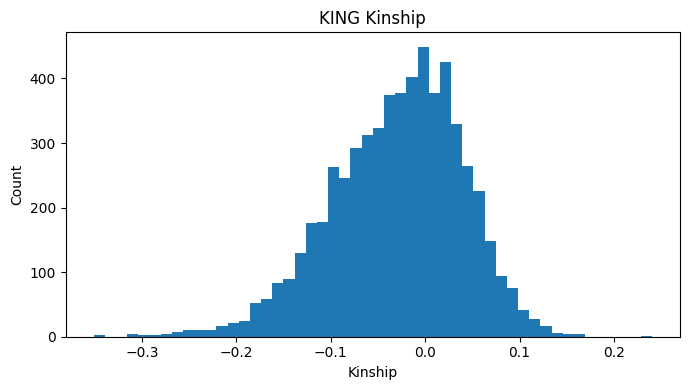

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(kin["Kinship"].dropna(), bins=50)
plt.title("KING Kinship")
plt.xlabel("Kinship")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from collections import Counter

cutoff = 0.0884  # 2nd-degree-or-closer threshold

# edges = related pairs above cutoff
edges = kin.loc[kin["Kinship"] > cutoff, ["ID1", "ID2", "Kinship"]].copy()
print("n edges:", len(edges))

# IDs involved in those edges
ids = pd.unique(pd.concat([edges["ID1"], edges["ID2"]], ignore_index=True))
keep = {sid: True for sid in ids}

edges2 = edges[["ID1", "ID2"]].copy()

# Greedy: repeatedly remove the individual involved in the most edges
while len(edges2) > 0:
    deg = Counter(edges2["ID1"].tolist() + edges2["ID2"].tolist())
    worst = max(deg, key=deg.get)
    keep[worst] = False
    edges2 = edges2[(edges2["ID1"] != worst) & (edges2["ID2"] != worst)]

unrelated_ids = [sid for sid, ok in keep.items() if ok]
print("unrelated_ids:", len(unrelated_ids))
print(unrelated_ids[:10])

n edges: 160
unrelated_ids: 58
['CCGPMC010_B0450', 'CCGPMC010_B0604', 'CCGPMC010_B0622', 'CCGPMC010_B0624', 'CCGPMC010_B0638', 'CCGPMC010_B0640', 'CCGPMC010_B0658', 'CCGPMC010_B0688', 'CCGPMC010_B0851', 'CCGPMC010_B0873']


In [7]:
import numpy as np
import pandas as pd

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# ids58 should be a Python list of sample IDs (strings)
# Example: ids58 = unrelated_ids  (if you already built it in Python)
ids58 = list(unrelated_ids)  # <-- you must define unrelated_ids somewhere

# subset KING pairs to only those within ids58
kin58 = kin[kin["ID1"].isin(ids58) & kin["ID2"].isin(ids58)].copy()

# initialize kinship matrix K (0 on diagonal; symmetric)
id_to_i = {sid: i for i, sid in enumerate(ids58)}
K = np.zeros((len(ids58), len(ids58)), dtype=float)

for _, row in kin58.iterrows():
    i = id_to_i[row["ID1"]]
    j = id_to_i[row["ID2"]]
    k = float(row["Kinship"])
    K[i, j] = k
    K[j, i] = k

# distance matrix: D = 1 - K
D = 1.0 - K

# convert square distance matrix to condensed form for scipy
# (scipy expects a condensed distance vector)
condensed = squareform(D, checks=False)

# average linkage clustering (equivalent to hclust(..., method="average"))
Z = linkage(condensed, method="average")

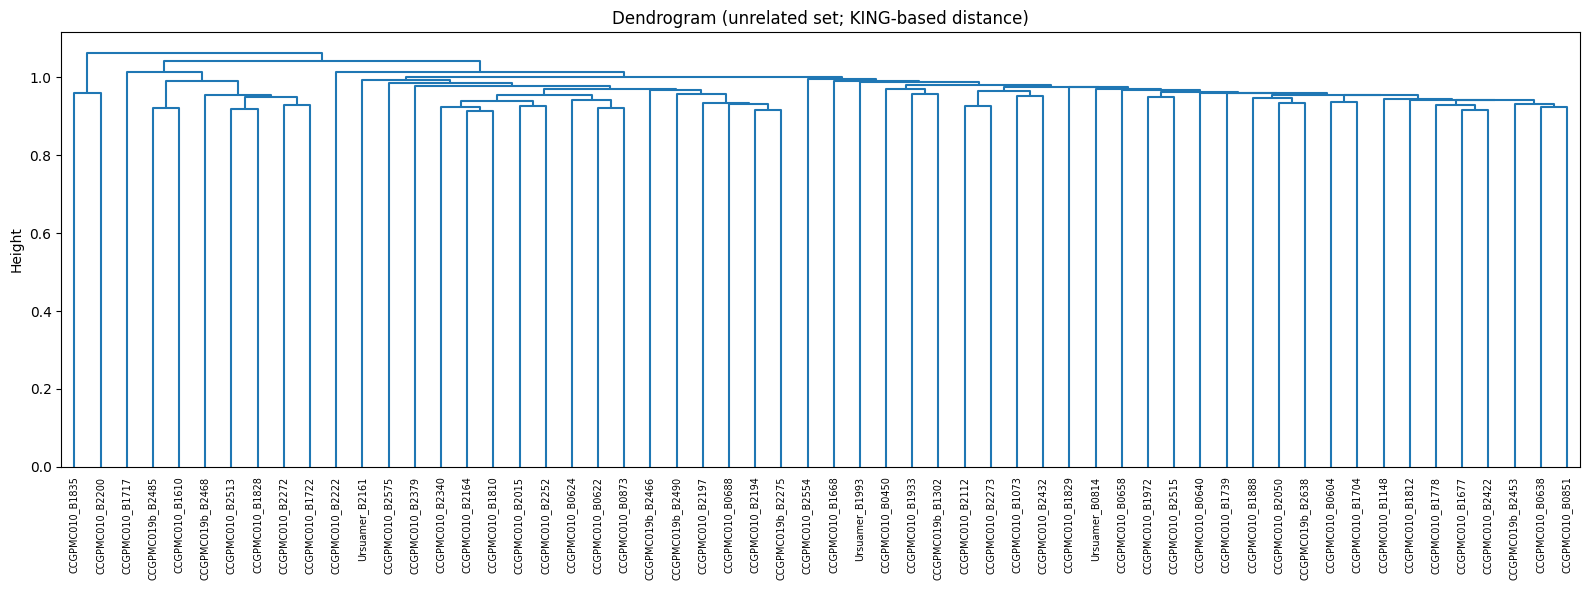

In [8]:
plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    labels=ids58,
    leaf_rotation=90,
    leaf_font_size=7
)
plt.title("Dendrogram (unrelated set; KING-based distance)")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

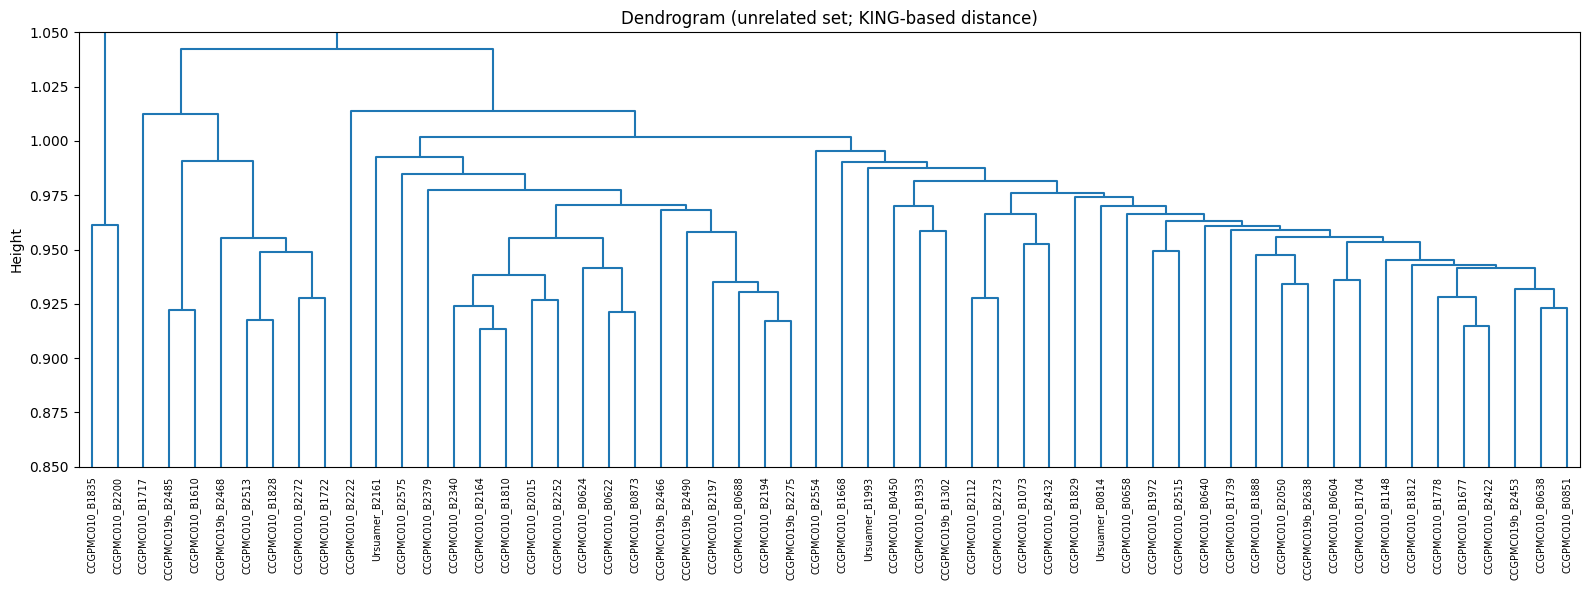

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, labels=ids58, leaf_rotation=90, leaf_font_size=7, ax=ax)
ax.set_title("Dendrogram (unrelated set; KING-based distance)")
ax.set_ylabel("Height")

# zoom: adjust these after you look once
ax.set_ylim(0.85, 1.05)

plt.tight_layout()
plt.show()